# Revenue Stability Over Time

By Mahesh Kanchipal & Nikhil M

## 1. Data Understanding

##### Dataset Description & Source

- **Dataset:** Fortune 500 Companies (2020–2023)
- **Source:** Kaggle — Fortune 500 Company Dataset
- **File used:** `Fortuene500-Company-100-Dataset.csv`
- **Coverage:** Fortune 500 companies tracked across 4 years (2020, 2021, 2022, 2023)
- **Variables:** 15+ features including revenue, profit, market value, assets, employees, sector, CEO demographics, and global ranking indicators.
- **Target Variable:** `revenue_mil` (primary), with secondary focus on `profit_mil` and `market_value_mil` for stability analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Fortuene500-Company-100-Dataset.csv')

# ── Derived / helper columns ──
df['profit_margin'] = df['profit_mil'] / df['revenue_mil'] * 100
df['revenue_per_employee'] = df['revenue_mil'] / df['employees']
df['return_on_assets']     = df['profit_mil'] / df['asset_mil'] * 100

df.head()


,name,rank,year,industry,sector,headquarters_state,headquarters_city,market_value_mil,revenue_mil,profit_mil,asset_mil,employees,founder_is_ceo,female_ceo,newcomer_to_fortune_500,global_500,profit_margin,revenue_per_employee,return_on_assets
0,Walmart,1,2020,General Merchandisers,Retailing,AR,Bentonville,321803.0,523964,14881.0,236495,2200000.0,no,no,no,yes,2.840081,0.238165,6.292311
1,Amazon,2,2020,Internet Services and Retailing,Retailing,WA,Seattle,970680.0,280522,11588.0,225248,798000.0,yes,no,no,yes,4.130870,0.351531,5.144552
2,Exxon Mobil,3,2020,Petroleum Refining,Energy,TX,Irving,160696.0,264938,14340.0,362597,74900.0,no,no,no,yes,5.412587,3.537223,3.954804
3,Apple,4,2020,"Computers, Office Equipment",Technology,CA,Cupertino,1112641.0,260174,55256.0,338516,137000.0,no,no,no,yes,21.238095,1.899080,16.323010
4,CVS Health,5,2020,Health Care: Pharmacy and Other Services,Health Care,RI,Woonsocket,77376.0,256776,6634.0,222449,290000.0,no,yes,no,yes,2.583575,0.885434,2.982257


In [2]:
print('DATA overview')
print("Observations :", df.shape[0])
print("Variables    :", df.shape[1])
print("Years covered:", (df['year'].unique()))
print("Companies    :",df['name'].unique())
print("Sectors      : ",df['sector'].unique())
print('--- Data Types ---')
print(df.dtypes)
print('--- Missing Values ---')
print(df.isnull().sum())


DATA overview
Observations : 2000
Variables    : 19
Years covered: [2020 2021 2022 2023]
Companies    : ['Walmart' 'Amazon' 'Exxon Mobil' 'Apple' 'CVS Health'
 'Berkshire Hathaway' 'UnitedHealth Group' 'McKesson' 'AT&T'
 'AmerisourceBergen' 'Alphabet' 'Ford Motor' 'Cigna' 'Costco Wholesale'
 'Chevron' 'Cardinal Health' 'JPMorgan Chase' 'General Motors'
 'Walgreens Boots Alliance' 'Verizon Communications' 'Microsoft'
 'Marathon Petroleum' 'Kroger' 'Fannie Mae' 'Bank of America' 'Home Depot'
 'Phillips 66' 'Comcast' 'Elevance Health' 'Wells Fargo' 'Citigroup'
 'Valero Energy' 'General Electric' 'Dell Technologies'
 'Johnson & Johnson' 'State Farm Insurance' 'Target' 'IBM'
 'Raytheon Technologies' 'Boeing' 'Freddie Mac' 'Centene' 'UPS' "Lowe's"
 'Intel' 'Meta Platforms' 'FedEx' 'MetLife' 'Walt Disney'
 'Procter & Gamble' 'PepsiCo' 'Humana' 'Prudential Financial'
 'Archer Daniels Midland' 'Albertsons' 'Sysco' 'Lockheed Martin' 'HP'
 'Energy Transfer' 'Goldman Sachs Group' 'Morgan Stanley' 

In [3]:
# Variable classification
print("NUMERICAL CONTINUOUS  :", ['market_value_mil','revenue_mil','profit_mil','asset_mil','profit_margin','revenue_per_employee','return_on_assets'])
print("NUMERICAL DISCRETE    :", ['rank','year','employees'])
print("CATEGORICAL NOMINAL   :", ['name','industry','headquarters_state','headquarters_city'])
print("CATEGORICAL ORDINAL   :", ['rank'])
print("CATEGORICAL BINARY    :", ['founder_is_ceo','female_ceo','newcomer_to_fortune_500','global_500'])
print("TARGET VARIABLE(S)    :", ['revenue_mil','profit_mil','market_value_mil'])
print()
print('--- Tabular Preview ---')
df[['name','rank','year','sector','revenue_mil','profit_mil','market_value_mil','employees']].head(10)


NUMERICAL CONTINUOUS  : ['market_value_mil', 'revenue_mil', 'profit_mil', 'asset_mil', 'profit_margin', 'revenue_per_employee', 'return_on_assets']
NUMERICAL DISCRETE    : ['rank', 'year', 'employees']
CATEGORICAL NOMINAL   : ['name', 'industry', 'headquarters_state', 'headquarters_city']
CATEGORICAL ORDINAL   : ['rank']
CATEGORICAL BINARY    : ['founder_is_ceo', 'female_ceo', 'newcomer_to_fortune_500', 'global_500']
TARGET VARIABLE(S)    : ['revenue_mil', 'profit_mil', 'market_value_mil']

--- Tabular Preview ---


,name,rank,year,sector,revenue_mil,profit_mil,market_value_mil,employees
0,Walmart,1,2020,Retailing,523964,14881.0,321803.0,2200000.0
1,Amazon,2,2020,Retailing,280522,11588.0,970680.0,798000.0
2,Exxon Mobil,3,2020,Energy,264938,14340.0,160696.0,74900.0
3,Apple,4,2020,Technology,260174,55256.0,1112641.0,137000.0
4,CVS Health,5,2020,Health Care,256776,6634.0,77376.0,290000.0
5,Berkshire Hathaway,6,2020,Financials,254616,81417.0,442897.0,391500.0
6,UnitedHealth Group,7,2020,Health Care,242155,13839.0,236555.0,325000.0
7,McKesson,8,2020,Health Care,214319,34.0,21845.0,70000.0
8,AT&T,9,2020,Telecommunications,181193,13903.0,209388.0,247800.0
9,AmerisourceBergen,10,2020,Health Care,179589,855.0,18221.0,21500.0


## 2. Descriptive Statistical Analysis (Mandatory)


In [4]:
num_cols = ['revenue_mil','profit_mil','market_value_mil']

print('OVERALL DESCRIPTIVE STATISTICS')
print('='*70)
desc = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['variance'] = df[num_cols].var().values
desc['IQR']      = desc['75%'] - desc['25%']
print(desc.round(2).to_string())


OVERALL DESCRIPTIVE STATISTICS
                   count      mean        std     min      25%      50%       75%        max      variance       IQR
revenue_mil       2000.0  31103.54   52515.49  5371.0  8984.25  14101.5  26989.75   611289.0  2.757877e+09  18005.50
profit_mil        1999.0   3196.27    7116.38     0.0   528.50   1241.0   3008.50    99803.0  5.064287e+07   2480.00
market_value_mil  1898.0  64929.37  179985.50    10.0  7938.25  20873.5  55208.50  2849538.0  3.239478e+10  47270.25


In [5]:
# ── Per-company stats (multi-year) ──────────────────────────────────────────
print('PER-COMPANY STATISTICS (mean, std across years)')
print('='*70)
company_stats = df.groupby('name')[num_cols].agg(['mean','std']).round(2)
print(company_stats.head(30).to_string())


PER-COMPANY STATISTICS (mean, std across years)
                            revenue_mil           profit_mil           market_value_mil           
                                   mean       std       mean       std             mean        std
name                                                                                              
3M                             33476.00   1587.71    5413.00    606.09         83218.50   22135.45
A-Mark Precious Metals          7077.67   1426.44     108.00     68.04           688.67     287.16
ABM Industries                  6764.67    938.15     119.00    115.21          2672.00     936.03
AECOM                          16043.00   3021.81     232.75     65.00          9194.50    3113.67
AES                            10901.75   1297.34     326.00    211.52         15125.75    4143.61
AGCO                           10495.00   1730.60     584.75    377.24          8841.50    3547.25
AIG                            50494.00   5291.26    7239.00 

In [6]:
# ── Per-sector stats ──────────────────────────────────────────────────────
print('PER-SECTOR STATISTICS')
print('='*70)
sector_stats = df.groupby('sector')[['revenue_mil','profit_mil','market_value_mil','employees']].agg(
    ['mean','median','std','min','max']).round(2)
print(sector_stats.to_string())


PER-SECTOR STATISTICS
                              revenue_mil                                   profit_mil                                   market_value_mil                                         employees                                         
                                     mean   median        std   min     max       mean  median       std    min      max             mean   median        std     min        max       mean    median        std      min        max
sector                                                                                                                                                                                                                              
Aerospace & Defense              36890.09  36602.0   23500.33  7863   77046    3151.74  3189.0   2624.43  309.0  11873.0         61629.17  51482.0   46372.38  2507.0   148665.0   92697.14   95000.0   54608.97  18200.0   243200.0
Apparel                          15115.80   9089.5   14036.53 

In [7]:
# ── Five-Number Summary ─────────────────────────────────────────────────────
print('FIVE-NUMBER SUMMARY')
print('='*70)
for col in num_cols:
    q0, q1, q2, q3, q4 = df[col].quantile([0,0.25,0.5,0.75,1.0])
    print(f"{col:25s}  Min={q0:>14,.0f}  Q1={q1:>14,.0f}  Median={q2:>14,.0f}  Q3={q3:>14,.0f}  Max={q4:>14,.0f}")


FIVE-NUMBER SUMMARY
revenue_mil                Min=         5,371  Q1=         8,984  Median=        14,102  Q3=        26,990  Max=       611,289
profit_mil                 Min=             0  Q1=           528  Median=         1,241  Q3=         3,008  Max=        99,803
market_value_mil           Min=            10  Q1=         7,938  Median=        20,874  Q3=        55,208  Max=     2,849,538


In [8]:
# ── Outlier Detection via IQR ───────────────────────────────────────────────
print('='*70)
print('OUTLIER DETECTION (IQR METHOD)')
print('='*70)
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)
    print(f"{col:25s}: {len(outliers):4d} outliers | lower fence={lower:>12,.0f} | upper fence={upper:>12,.0f}")

print()
print('Top outlier companies by revenue:')
Q1 = df['revenue_mil'].quantile(0.25); Q3 = df['revenue_mil'].quantile(0.75)
IQR = Q3 - Q1
print(df[df['revenue_mil'] > Q3 + 1.5*IQR][['name','year','revenue_mil']].sort_values('revenue_mil', ascending=False).head(10).to_string())


OUTLIER DETECTION (IQR METHOD)
revenue_mil              :  260 outliers | lower fence=     -18,024 | upper fence=      53,998
profit_mil               :  209 outliers | lower fence=      -3,192 | upper fence=       6,728
market_value_mil         :  214 outliers | lower fence=     -62,967 | upper fence=     126,114

Top outlier companies by revenue:
             name  year  revenue_mil
1500      Walmart  2023       611289
1000      Walmart  2022       572754
500       Walmart  2021       559151
0         Walmart  2020       523964
1501       Amazon  2023       513983
1001       Amazon  2022       469822
1502  Exxon Mobil  2023       413680
1503        Apple  2023       394328
501        Amazon  2021       386064
1002        Apple  2022       365817


## 3. Mandatory Visualizations
### 3.1 Distribution Plots — Histograms


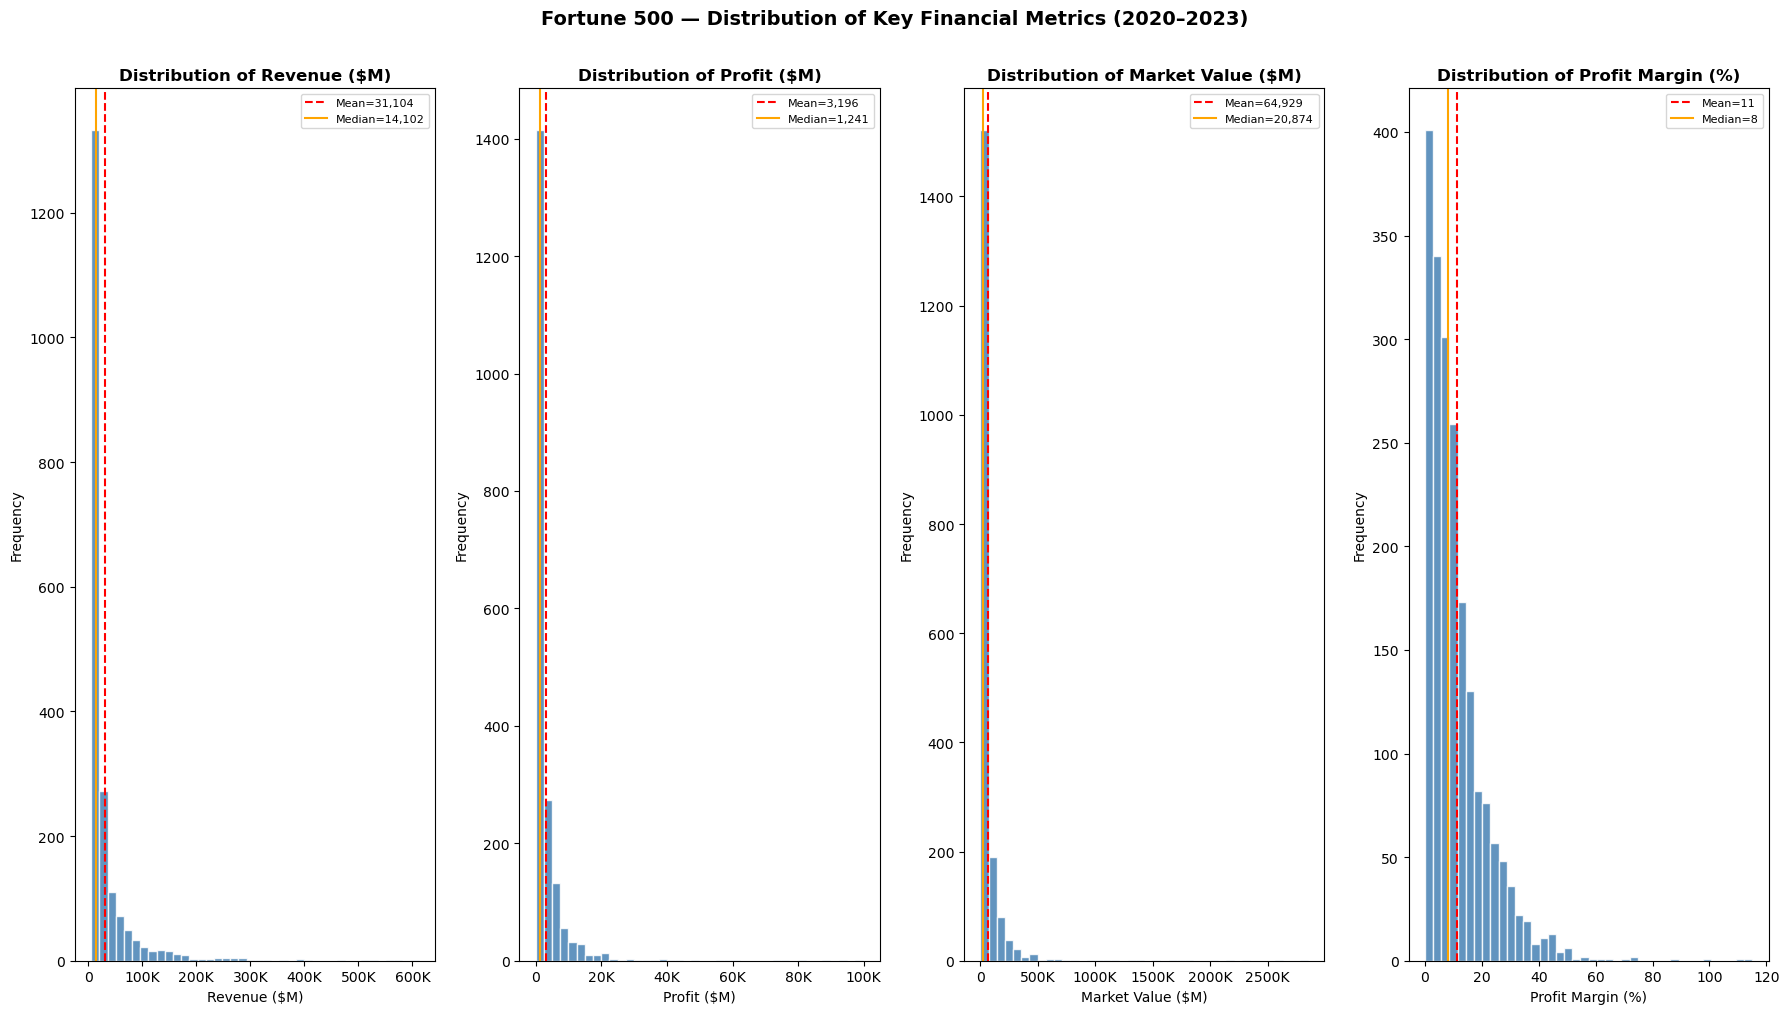

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 10))
axes = axes.flatten()
plot_cols = ['revenue_mil','profit_mil','market_value_mil','profit_margin']
titles    = ['Revenue ($M)','Profit ($M)','Market Value ($M)','Profit Margin (%)']

for i, (col, title) in enumerate(zip(plot_cols, titles)):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():,.0f}')
    axes[i].axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Median={data.median():,.0f}')
    axes[i].set_title(f'Distribution of {title}', fontweight='bold')
    axes[i].set_xlabel(title); axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x>=1000 else f'{x:.0f}'))

plt.suptitle('Fortune 500 — Distribution of Key Financial Metrics (2020–2023)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 3.2 Box Plots — Sector-Level Comparisons

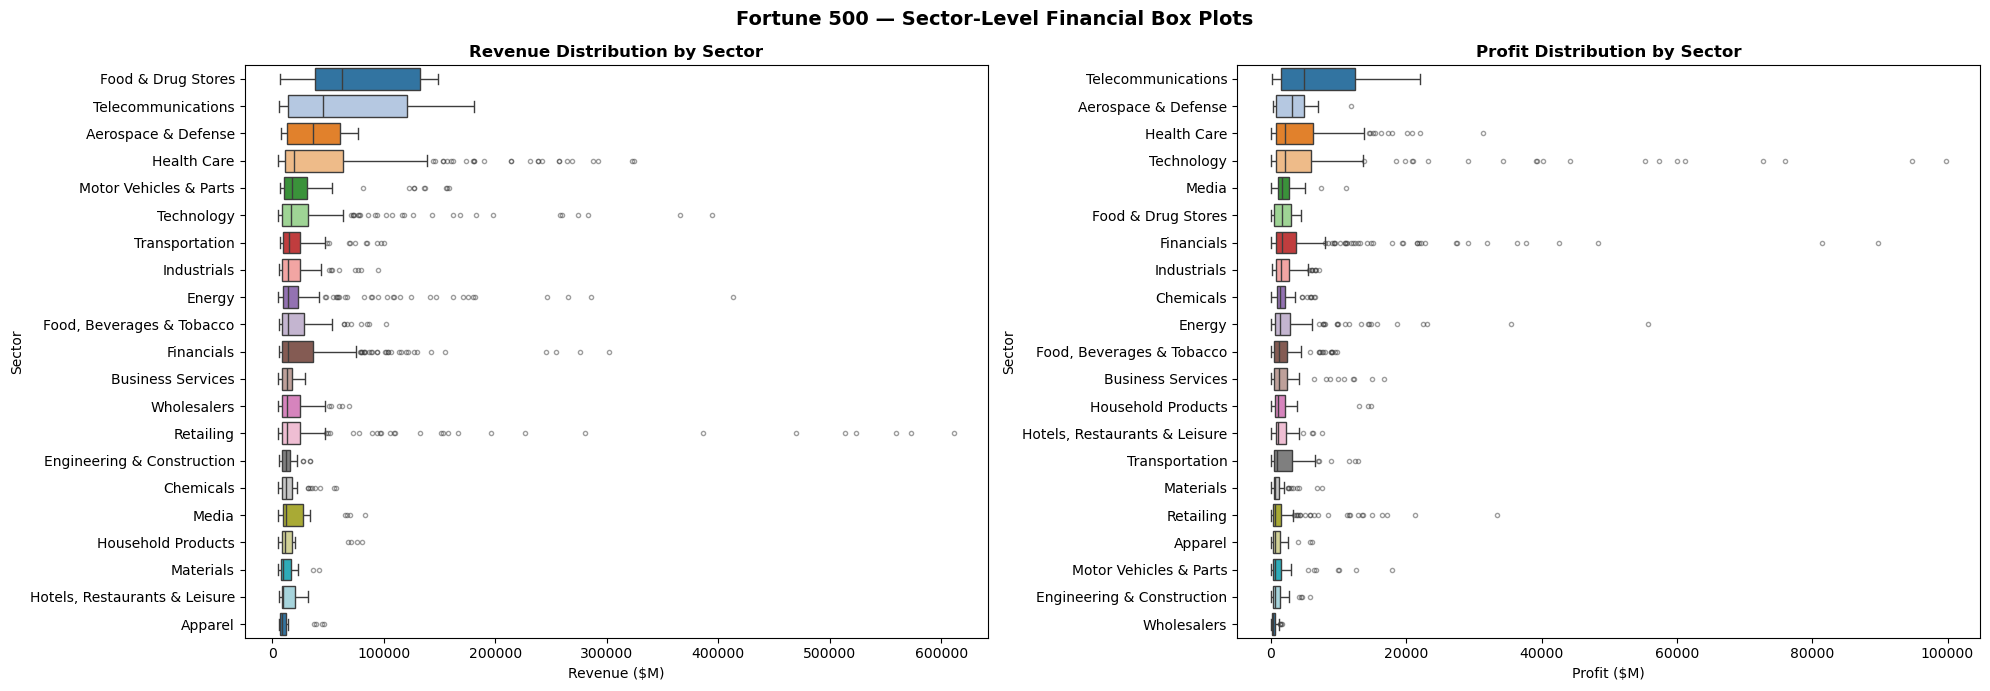

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Revenue by sector
order_rev = df.groupby('sector')['revenue_mil'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='sector', x='revenue_mil', order=order_rev, ax=axes[0],
            palette='tab20', flierprops=dict(marker='o', markersize=3, alpha=0.5))
axes[0].set_title('Revenue Distribution by Sector', fontweight='bold')
axes[0].set_xlabel('Revenue ($M)'); axes[0].set_ylabel('Sector')

# Profit by sector
order_prof = df.groupby('sector')['profit_mil'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='sector', x='profit_mil', order=order_prof, ax=axes[1],
            palette='tab20', flierprops=dict(marker='o', markersize=3, alpha=0.5))
axes[1].set_title('Profit Distribution by Sector', fontweight='bold')
axes[1].set_xlabel('Profit ($M)'); axes[1].set_ylabel('Sector')

plt.suptitle('Fortune 500 — Sector-Level Financial Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### 3.3 Bar Graph — Company Count per Sector

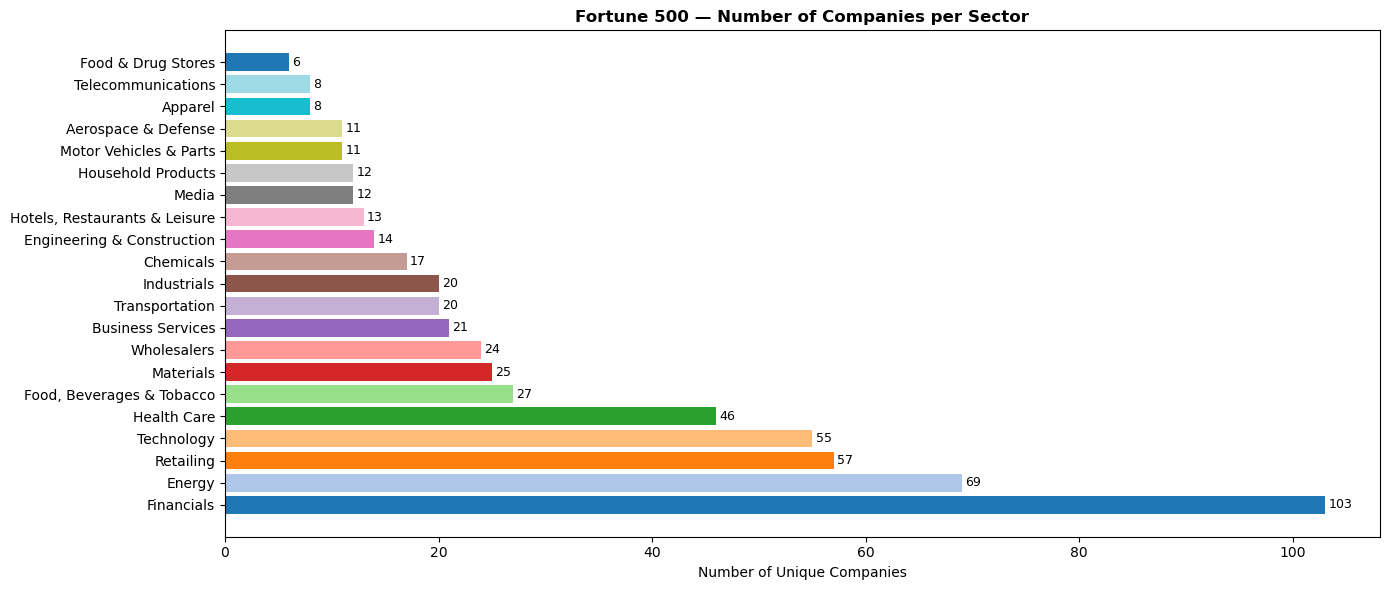

In [11]:
sector_count = df.drop_duplicates('name').groupby('sector').size().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.barh(sector_count.index, sector_count.values, color=sns.color_palette('tab20', len(sector_count)))
plt.xlabel('Number of Unique Companies')
plt.title('Fortune 500 — Number of Companies per Sector', fontweight='bold')
for bar, val in zip(bars, sector_count.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout(); plt.show()


### 3.4 Scatter Plot — Revenue vs Profit (coloured by Sector)

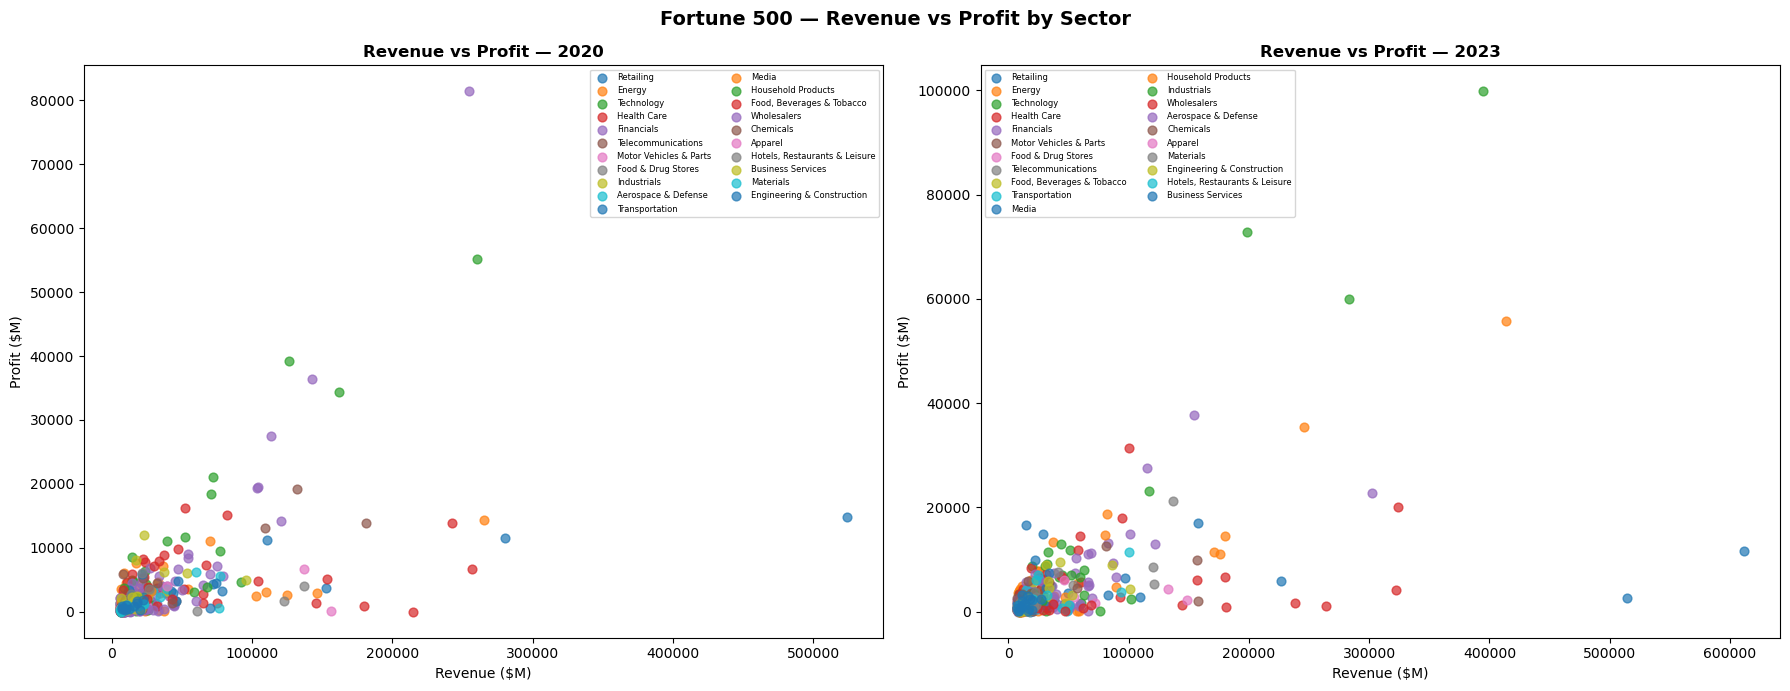

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 2020 snapshot
df20 = df[df['year']==2020]
for sector in df20['sector'].unique():
    sub = df20[df20['sector']==sector]
    axes[0].scatter(sub['revenue_mil'], sub['profit_mil'], label=sector, alpha=0.7, s=40)
axes[0].set_xlabel('Revenue ($M)'); axes[0].set_ylabel('Profit ($M)')
axes[0].set_title('Revenue vs Profit — 2020', fontweight='bold')
axes[0].legend(fontsize=6, ncol=2)

# 2023 snapshot
df23 = df[df['year']==2023]
for sector in df23['sector'].unique():
    sub = df23[df23['sector']==sector]
    axes[1].scatter(sub['revenue_mil'], sub['profit_mil'], label=sector, alpha=0.7, s=40)
axes[1].set_xlabel('Revenue ($M)'); axes[1].set_ylabel('Profit ($M)')
axes[1].set_title('Revenue vs Profit — 2023', fontweight='bold')
axes[1].legend(fontsize=6, ncol=2)

plt.suptitle('Fortune 500 — Revenue vs Profit by Sector', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### 3.5 Line Plot — Average Revenue & Profit Trends Over Years

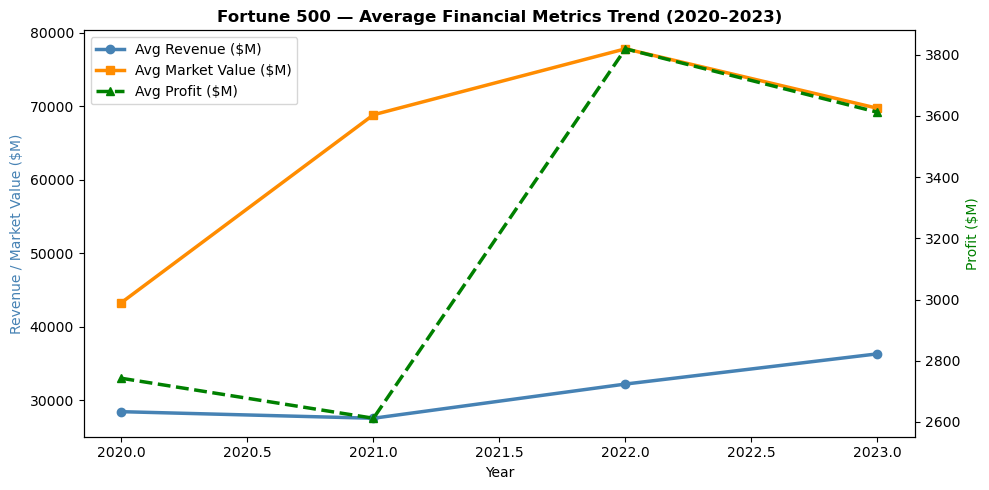

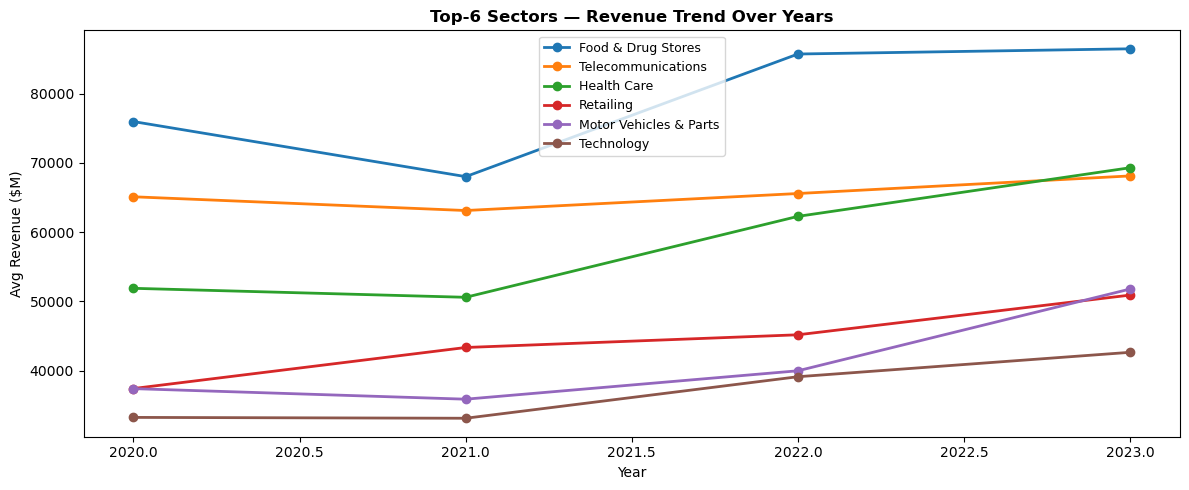

In [13]:
yearly = df.groupby('year')[['revenue_mil','profit_mil','market_value_mil']].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(yearly.index, yearly['revenue_mil'],     marker='o', color='steelblue', linewidth=2.5, label='Avg Revenue ($M)')
ax1.plot(yearly.index, yearly['market_value_mil'],marker='s', color='darkorange', linewidth=2.5, label='Avg Market Value ($M)')
ax2.plot(yearly.index, yearly['profit_mil'],      marker='^', color='green',     linewidth=2.5, label='Avg Profit ($M)', linestyle='--')

ax1.set_xlabel('Year'); ax1.set_ylabel('Revenue / Market Value ($M)', color='steelblue')
ax2.set_ylabel('Profit ($M)', color='green')
ax1.set_title('Fortune 500 — Average Financial Metrics Trend (2020–2023)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout(); plt.show()

# ── Per-sector revenue trend ──────────────────────────────────────────────────
top_sectors = df.groupby('sector')['revenue_mil'].mean().nlargest(6).index
sector_yearly = df[df['sector'].isin(top_sectors)].groupby(['year','sector'])['revenue_mil'].mean().reset_index()

plt.figure(figsize=(12, 5))
for sec in top_sectors:
    sub = sector_yearly[sector_yearly['sector']==sec]
    plt.plot(sub['year'], sub['revenue_mil'], marker='o', linewidth=2, label=sec)
plt.xlabel('Year'); plt.ylabel('Avg Revenue ($M)')
plt.title('Top-6 Sectors — Revenue Trend Over Years', fontweight='bold')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()


### 3.6 Grouped Bar Chart — Average Profit by Sector & Year

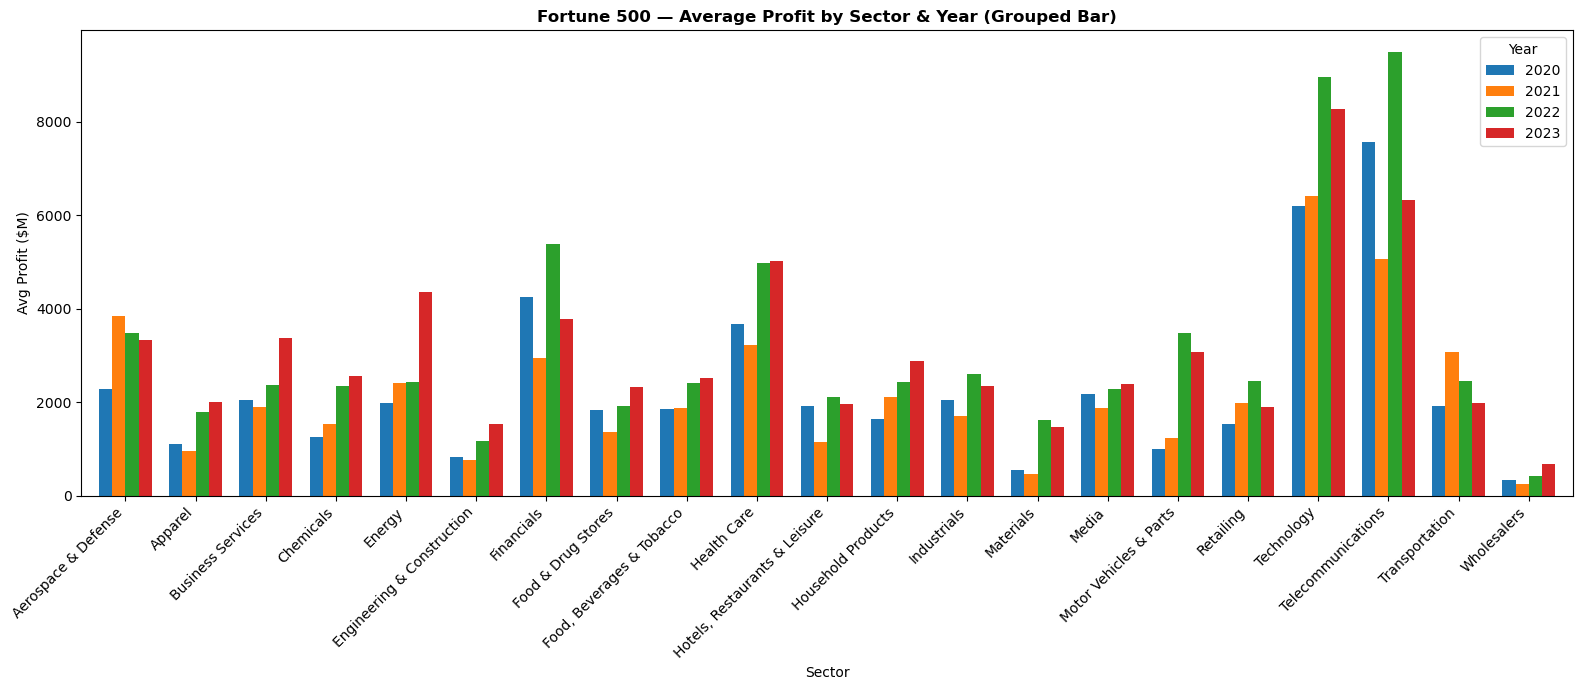

In [14]:
pivot = df.groupby(['sector','year'])['profit_mil'].mean().unstack()

pivot.plot(kind='bar', figsize=(16, 7), width=0.75)
plt.xlabel('Sector'); plt.ylabel('Avg Profit ($M)')
plt.title('Fortune 500 — Average Profit by Sector & Year (Grouped Bar)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout(); plt.show()


### 3.7 Stacked Bar Chart — Total Revenue by Sector & Year

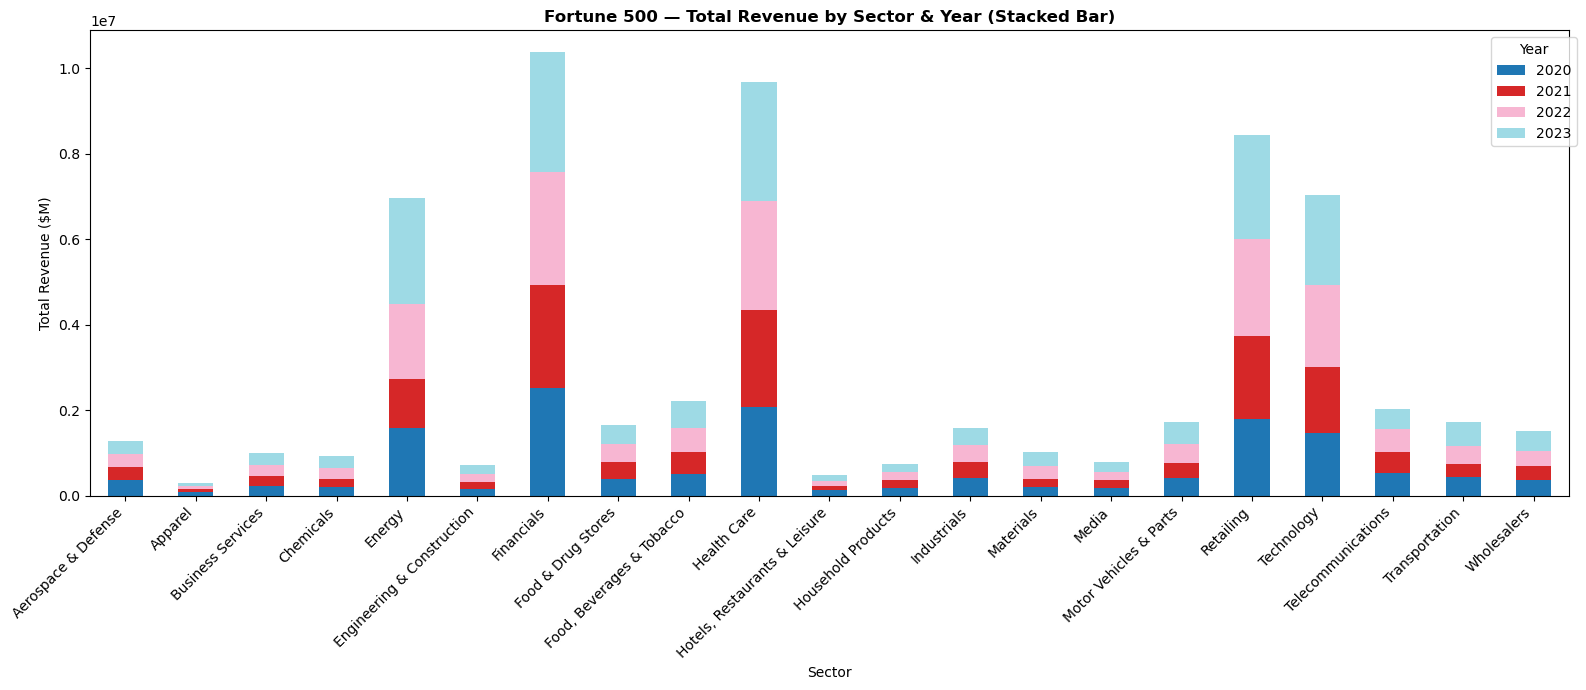

In [15]:
pivot_rev = df.groupby(['sector','year'])['revenue_mil'].sum().unstack()

pivot_rev.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab20')
plt.xlabel('Sector'); plt.ylabel('Total Revenue ($M)')
plt.title('Fortune 500 — Total Revenue by Sector & Year (Stacked Bar)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()


### 3.8 Correlation Heatmap

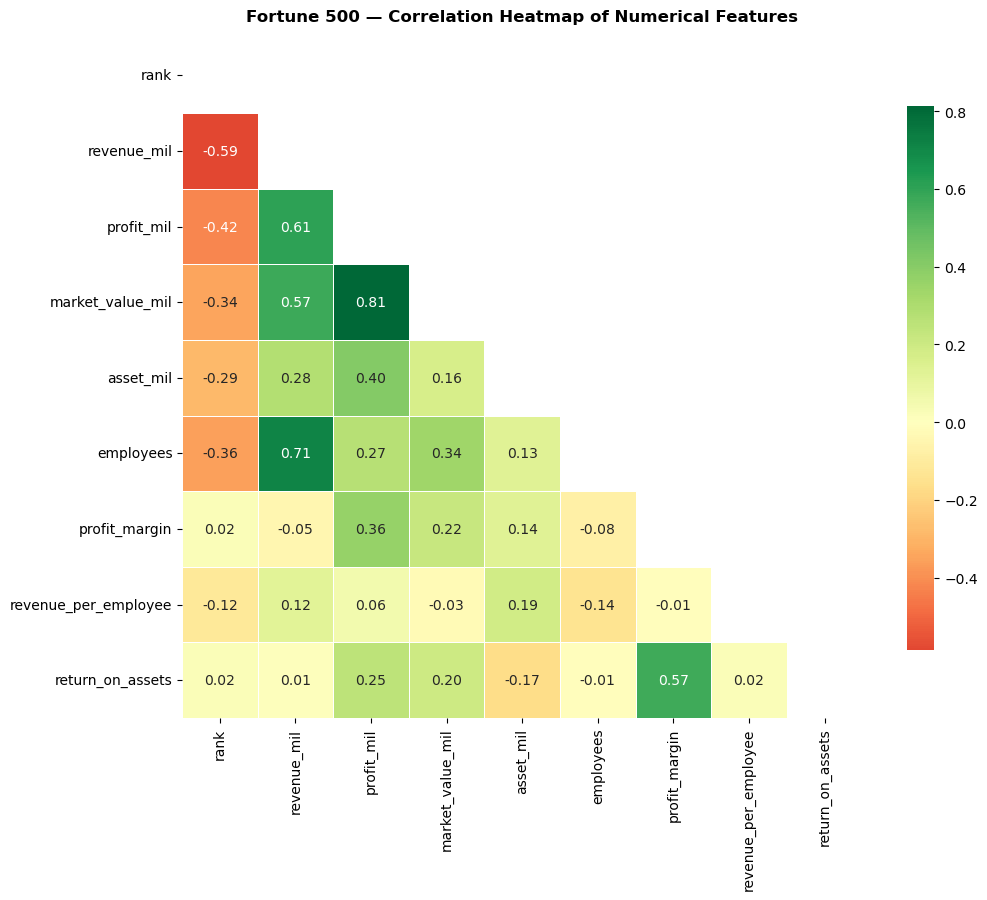

Key correlations:
market_value_mil        0.814072
revenue_mil             0.605848
asset_mil               0.404598
profit_margin           0.363431
employees               0.271186
return_on_assets        0.245834
revenue_per_employee    0.055557
rank                   -0.421647


In [16]:
num_df = df[['rank','revenue_mil','profit_mil','market_value_mil','asset_mil','employees',
              'profit_margin','revenue_per_employee','return_on_assets']].dropna()

corr_matrix = num_df.corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Fortune 500 — Correlation Heatmap of Numerical Features', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

print("Key correlations:")
print(corr_matrix['profit_mil'].drop('profit_mil').sort_values(ascending=False).to_string())


### 3.9 Covariance Heatmap

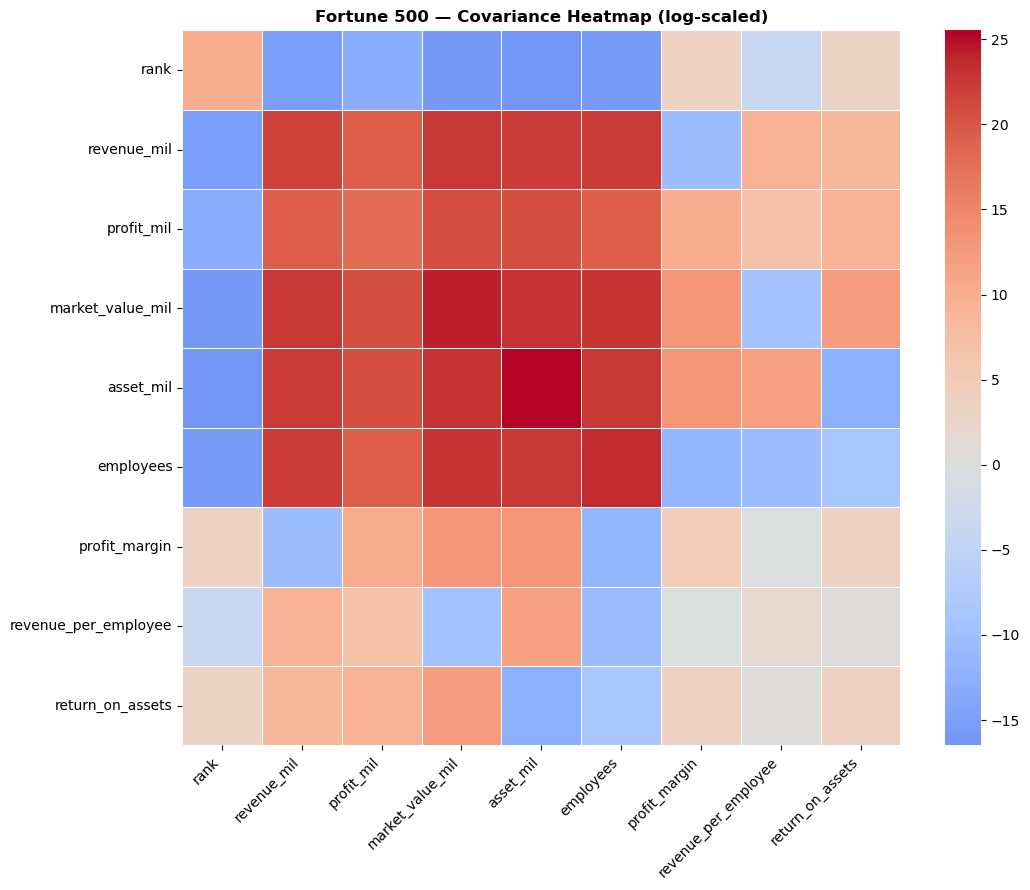

In [17]:
cov_matrix = num_df.cov()

plt.figure(figsize=(11, 9))
# Log-scale normalise for visibility
log_cov = np.sign(cov_matrix) * np.log1p(np.abs(cov_matrix))
sns.heatmap(log_cov, annot=False, cmap='coolwarm', center=0, linewidths=0.5,
            xticklabels=cov_matrix.columns, yticklabels=cov_matrix.columns)
plt.title('Fortune 500 — Covariance Heatmap (log-scaled)', fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


### 3.10 Scree Plot (PCA Explained Variance)

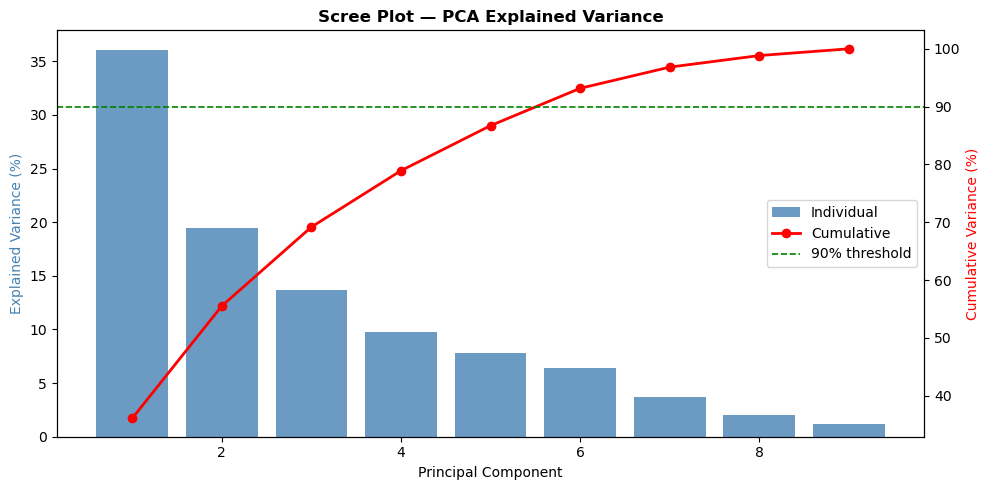

Components to reach 90% variance: 6


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

pca_full = PCA()
pca_full.fit(X_scaled)
ev = pca_full.explained_variance_ratio_
cumev = np.cumsum(ev)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(1, len(ev)+1), ev*100, color='steelblue', alpha=0.8, label='Individual')
ax2.plot(range(1, len(ev)+1), cumev*100, marker='o', color='red', linewidth=2, label='Cumulative')
ax2.axhline(90, color='green', linestyle='--', linewidth=1.2, label='90% threshold')
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax1.set_title('Scree Plot — PCA Explained Variance', fontweight='bold')
lines1,lbl1 = ax1.get_legend_handles_labels()
lines2,lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, loc='center right')
plt.tight_layout(); plt.show()

print("Components to reach 90% variance:", np.argmax(cumev >= 0.90) + 1)


### 3.11 2D PCA Projection

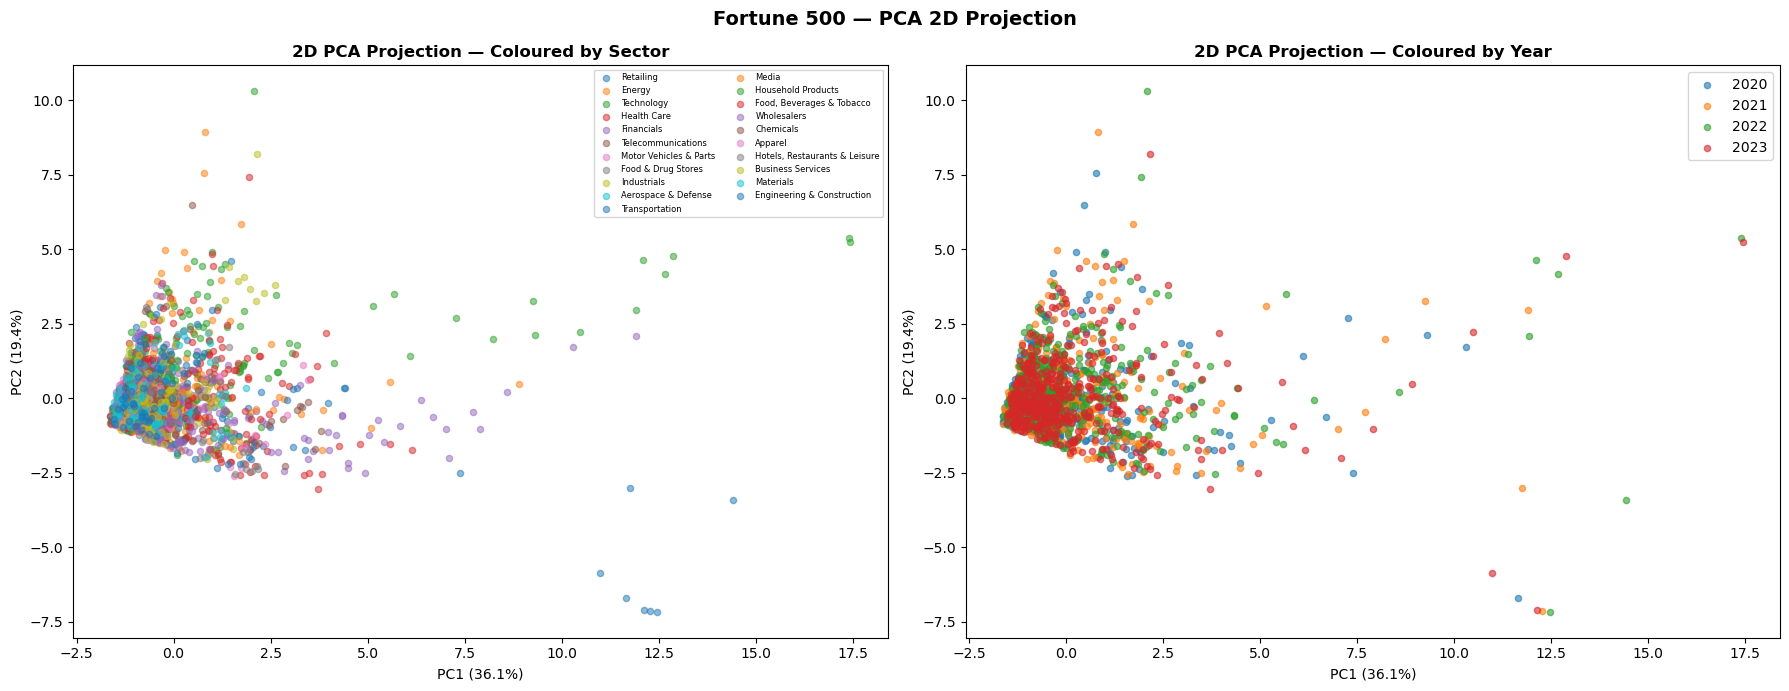

In [19]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

pca_df = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
                        'sector': num_df.reset_index(drop=True).index.map(lambda i: df['sector'].iloc[i]),
                        'year':   num_df.reset_index(drop=True).index.map(lambda i: df['year'].iloc[i])})
# safer sector assignment
pca_df['sector'] = df.loc[num_df.index, 'sector'].values
pca_df['year']   = df.loc[num_df.index, 'year'].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# by sector
sectors = pca_df['sector'].unique()
for sec in sectors:
    sub = pca_df[pca_df['sector']==sec]
    axes[0].scatter(sub['PC1'], sub['PC2'], label=sec, alpha=0.5, s=20)
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].set_title('2D PCA Projection — Coloured by Sector', fontweight='bold')
axes[0].legend(fontsize=6, ncol=2)

# by year
for yr in sorted(pca_df['year'].unique()):
    sub = pca_df[pca_df['year']==yr]
    axes[1].scatter(sub['PC1'], sub['PC2'], label=str(yr), alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].set_title('2D PCA Projection — Coloured by Year', fontweight='bold')
axes[1].legend()

plt.suptitle('Fortune 500 — PCA 2D Projection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Probability Analysis (Mandatory)


In [20]:
# ── Basic Probability ─────────────────────────────────────────────────────
print('='*60)
print('BASIC PROBABILITY CALCULATIONS')
print('='*60)

n_total = len(df)
p_global500     = (df['global_500']=='yes').sum() / n_total
p_female_ceo    = (df['female_ceo']=='yes').sum() / n_total
p_founder_ceo   = (df['founder_is_ceo']=='yes').sum() / n_total
p_newcomer      = (df['newcomer_to_fortune_500']=='yes').sum() / n_total
p_profitable    = (df['profit_mil'] > 0).sum() / n_total
p_high_margin   = (df['profit_margin'] > 10).sum() / n_total

print(f"P(Global 500)           = {p_global500:.4f}  ({p_global500*100:.2f}%)")
print(f"P(Female CEO)           = {p_female_ceo:.4f}  ({p_female_ceo*100:.2f}%)")
print(f"P(Founder is CEO)       = {p_founder_ceo:.4f}  ({p_founder_ceo*100:.2f}%)")
print(f"P(Newcomer)             = {p_newcomer:.4f}  ({p_newcomer*100:.2f}%)")
print(f"P(Profitable)           = {p_profitable:.4f}  ({p_profitable*100:.2f}%)")
print(f"P(Profit Margin > 10%)  = {p_high_margin:.4f}  ({p_high_margin*100:.2f}%)")


BASIC PROBABILITY CALCULATIONS
P(Global 500)           = 0.2385  (23.85%)
P(Female CEO)           = 0.0935  (9.35%)
P(Founder is CEO)       = 0.0365  (3.65%)
P(Newcomer)             = 0.0600  (6.00%)
P(Profitable)           = 0.9990  (99.90%)
P(Profit Margin > 10%)  = 0.4180  (41.80%)


In [21]:
# ── Conditional Probability ──────────────────────────────────────────────
print('='*60)
print('CONDITIONAL PROBABILITY CALCULATIONS')
print('='*60)

# P(Global 500 | Technology sector)
tech = df[df['sector']=='Technology']
p_g500_given_tech = (tech['global_500']=='yes').sum() / len(tech)

# P(Profitable | Financials sector)
fin = df[df['sector']=='Financials']
p_prof_given_fin  = (fin['profit_mil'] > 0).sum() / len(fin)

# P(Female CEO | sector)
female_by_sector = df.groupby('sector').apply(lambda x: (x['female_ceo']=='yes').sum() / len(x))

print(f"P(Global500 | Technology)    = {p_g500_given_tech:.4f}  ({p_g500_given_tech*100:.1f}%)")
print(f"P(Profitable | Financials)   = {p_prof_given_fin:.4f}  ({p_prof_given_fin*100:.1f}%)")
print()
print("P(Female CEO | Sector):")
print(female_by_sector.sort_values(ascending=False).round(4).to_string())


CONDITIONAL PROBABILITY CALCULATIONS
P(Global500 | Technology)    = 0.2646  (26.5%)
P(Profitable | Financials)   = 1.0000  (100.0%)

P(Female CEO | Sector):
sector
Food & Drug Stores               0.3333
Aerospace & Defense              0.2286
Retailing                        0.1466
Household Products               0.1190
Hotels, Restaurants & Leisure    0.1143
Technology                       0.1111
Health Care                      0.1084
Industrials                      0.0986
Financials                       0.0959
Motor Vehicles & Parts           0.0952
Food, Beverages & Tobacco        0.0800
Materials                        0.0732
Chemicals                        0.0690
Energy                           0.0628
Transportation                   0.0580
Engineering & Construction       0.0566
Business Services                0.0541
Wholesalers                      0.0506
Apparel                          0.0500
Telecommunications               0.0323
Media                            0.0

In [22]:
# ── Bayes' Theorem ────────────────────────────────────────────────────────
print('='*60)
print("BAYES' THEOREM APPLICATION")
print('='*60)
print()
print("Question: Given a company is in the Technology sector,")
print("          what is the probability it is also in Global 500?")
print()

# P(Global500 | Tech) using Bayes:
#   P(Tech | Global500) * P(Global500) / P(Tech)
p_tech          = (df['sector']=='Technology').sum() / n_total
g500_df         = df[df['global_500']=='yes']
p_tech_given_g500 = (g500_df['sector']=='Technology').sum() / len(g500_df)

bayes_result = (p_tech_given_g500 * p_global500) / p_tech

print(f"  P(Tech)                    = {p_tech:.4f}")
print(f"  P(Global500)               = {p_global500:.4f}")
print(f"  P(Tech | Global500)        = {p_tech_given_g500:.4f}")
print(f"  P(Global500 | Tech) [Bayes]= {bayes_result:.4f}  ({bayes_result*100:.1f}%)")
print()
print(f"  Verification (direct count)= {p_g500_given_tech:.4f}  ✓ Results match!")
print()
print("Interpretation: Technology companies have a significantly higher probability")
print(f"  of being in the Global 500 ({bayes_result*100:.1f}%) compared to the overall average ({p_global500*100:.1f}%).")


BAYES' THEOREM APPLICATION

Question: Given a company is in the Technology sector,
          what is the probability it is also in Global 500?

  P(Tech)                    = 0.0945
  P(Global500)               = 0.2385
  P(Tech | Global500)        = 0.1048
  P(Global500 | Tech) [Bayes]= 0.2646  (26.5%)

  Verification (direct count)= 0.2646  ✓ Results match!

Interpretation: Technology companies have a significantly higher probability
  of being in the Global 500 (26.5%) compared to the overall average (23.8%).


In [23]:
# ── Normal Distribution fit for Revenue ─────────────────────────────────
mu, sigma = df['revenue_mil'].mean(), df['revenue_mil'].std()

# P(revenue > 100,000 M)
p_rev_gt_100k = 1 - norm.cdf(100000, loc=mu, scale=sigma)
# P(50,000 < revenue < 150,000)
p_rev_range   = norm.cdf(150000, mu, sigma) - norm.cdf(50000, mu, sigma)

print('='*60)
print('NORMAL DISTRIBUTION PROBABILITY (Revenue)')
print('='*60)
print(f"  Mean Revenue: {mu:,.0f} $M   Std: {sigma:,.0f} $M")
print(f"  P(Revenue > 100,000 M)           = {p_rev_gt_100k:.4f}  ({p_rev_gt_100k*100:.2f}%)")
print(f"  P(50,000 < Revenue < 150,000 M)  = {p_rev_range:.4f}  ({p_rev_range*100:.2f}%)")


NORMAL DISTRIBUTION PROBABILITY (Revenue)
  Mean Revenue: 31,104 $M   Std: 52,515 $M
  P(Revenue > 100,000 M)           = 0.0948  (9.48%)
  P(50,000 < Revenue < 150,000 M)  = 0.3477  (34.77%)


## 5. Inferential Statistics (Mandatory)
### 5.1 Confidence Intervals


In [24]:
from scipy import stats as st

print('='*60)
print('95% CONFIDENCE INTERVALS — REVENUE')
print('='*60)

# Overall CI
data = df['revenue_mil'].dropna()
n = len(data); xbar = data.mean(); s = data.std()
se = s / np.sqrt(n)
ci = st.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f"Overall         : ({ci[0]:>12,.2f}, {ci[1]:>12,.2f})  n={n}")

# By year
for yr in sorted(df['year'].unique()):
    d = df[df['year']==yr]['revenue_mil'].dropna()
    ci_yr = st.t.interval(0.95, df=len(d)-1, loc=d.mean(), scale=st.sem(d))
    print(f"Year {yr}       : ({ci_yr[0]:>12,.2f}, {ci_yr[1]:>12,.2f})  n={len(d)}")

print()
print('95% CONFIDENCE INTERVALS — PROFIT MARGIN by Top Sectors')
for sec in df.groupby('sector')['profit_margin'].mean().nlargest(5).index:
    d = df[df['sector']==sec]['profit_margin'].dropna()
    ci_s = st.t.interval(0.95, df=len(d)-1, loc=d.mean(), scale=st.sem(d))
    print(f"  {sec:30s}: ({ci_s[0]:>7.2f}%, {ci_s[1]:>7.2f}%)  mean={d.mean():.2f}%")


95% CONFIDENCE INTERVALS — REVENUE
Overall         : (   28,800.59,    33,406.48)  n=2000
Year 2020       : (   24,389.61,    32,450.79)  n=500
Year 2021       : (   23,346.37,    31,706.01)  n=500
Year 2022       : (   27,423.39,    36,935.07)  n=500
Year 2023       : (   30,941.71,    41,635.38)  n=500

95% CONFIDENCE INTERVALS — PROFIT MARGIN by Top Sectors
  Technology                    : (  14.30%,   18.25%)  mean=16.27%
  Business Services             : (  11.54%,   20.06%)  mean=15.80%
  Financials                    : (  12.98%,   15.07%)  mean=14.02%
  Chemicals                     : (  10.97%,   15.49%)  mean=13.23%
  Media                         : (   9.09%,   16.61%)  mean=12.85%


### 5.2 Hypothesis Testing — Z-test / T-test

In [25]:
print('='*70)
print('HYPOTHESIS TEST 1: Is average revenue significantly different between 2020 and 2023?')
print('='*70)
rev_2020 = df[df['year']==2020]['revenue_mil'].dropna()
rev_2023 = df[df['year']==2023]['revenue_mil'].dropna()

t_stat, p_val = st.ttest_ind(rev_2020, rev_2023, equal_var=False)
print(f"H0: Mean revenue 2020 == Mean revenue 2023")
print(f"H1: Mean revenue 2020 != Mean revenue 2023")
print(f"  Mean 2020: {rev_2020.mean():>12,.2f}  |  Mean 2023: {rev_2023.mean():>12,.2f}")
print(f"  t-statistic: {t_stat:.4f}   p-value: {p_val:.4f}")
print(f"  Decision (α=0.05): {'REJECT H0 — significant difference' if p_val<0.05 else 'FAIL TO REJECT H0'}")

print()
print('='*70)
print('HYPOTHESIS TEST 2: Do Technology companies have higher profit than Energy?')
print('='*70)
prof_tech   = df[df['sector']=='Technology']['profit_mil'].dropna()
prof_energy = df[df['sector']=='Energy']['profit_mil'].dropna()
t2, p2 = st.ttest_ind(prof_tech, prof_energy, equal_var=False, alternative='greater')
print(f"H0: Profit(Tech) <= Profit(Energy)  |  H1: Profit(Tech) > Profit(Energy)")
print(f"  Mean Tech: {prof_tech.mean():>10,.2f}  |  Mean Energy: {prof_energy.mean():>10,.2f}")
print(f"  t-stat: {t2:.4f}   p-value: {p2:.4f}")
print(f"  Decision: {'REJECT H0' if p2<0.05 else 'FAIL TO REJECT H0'}")


HYPOTHESIS TEST 1: Is average revenue significantly different between 2020 and 2023?
H0: Mean revenue 2020 == Mean revenue 2023
H1: Mean revenue 2020 != Mean revenue 2023
  Mean 2020:    28,420.20  |  Mean 2023:    36,288.54
  t-statistic: -2.3088   p-value: 0.0212
  Decision (α=0.05): REJECT H0 — significant difference

HYPOTHESIS TEST 2: Do Technology companies have higher profit than Energy?
H0: Profit(Tech) <= Profit(Energy)  |  H1: Profit(Tech) > Profit(Energy)
  Mean Tech:   7,508.58  |  Mean Energy:   2,845.05
  t-stat: 3.8753   p-value: 0.0001
  Decision: REJECT H0


### 5.3 Chi-Square Test

In [26]:
print('='*60)
print('CHI-SQUARE TEST: Female CEO vs Global 500')
print('='*60)
ct = pd.crosstab(df['female_ceo'], df['global_500'])
chi2, p_chi, dof, expected = chi2_contingency(ct)
print(ct)
print(f"\nChi2 = {chi2:.4f}  |  p-value = {p_chi:.4f}  |  dof = {dof}")
print(f"Decision: {'Significant association' if p_chi<0.05 else 'No significant association'} at α=0.05")


CHI-SQUARE TEST: Female CEO vs Global 500
global_500    no  yes
female_ceo           
no          1389  424
yes          134   53

Chi2 = 2.0274  |  p-value = 0.1545  |  dof = 1
Decision: No significant association at α=0.05


### 5.4 One-Way ANOVA — Profit across Sectors

In [27]:
print('='*60)
print('ONE-WAY ANOVA: Profit ($M) across Sectors')
print('='*60)
groups = [df[df['sector']==sec]['profit_mil'].dropna().values
          for sec in df['sector'].unique()]
F, p_anova = f_oneway(*groups)
print(f"F-statistic = {F:.4f}   p-value = {p_anova:.6f}")
print(f"Decision: {'REJECT H0 — at least one sector differs significantly' if p_anova<0.05 else 'FAIL TO REJECT H0'}")
print()
print("Sector mean profit:")
print(df.groupby('sector')['profit_mil'].mean().sort_values(ascending=False).round(2).to_string())


ONE-WAY ANOVA: Profit ($M) across Sectors
F-statistic = 6.9383   p-value = 0.000000
Decision: REJECT H0 — at least one sector differs significantly

Sector mean profit:
sector
Technology                       7508.58
Telecommunications               7060.73
Health Care                      4202.51
Financials                       4101.70
Aerospace & Defense              3151.74
Energy                           2845.05
Business Services                2428.61
Transportation                   2317.10
Household Products               2213.31
Motor Vehicles & Parts           2201.98
Media                            2166.45
Industrials                      2164.39
Food, Beverages & Tobacco        2158.77
Retailing                        1970.41
Chemicals                        1960.26
Food & Drug Stores               1839.33
Hotels, Restaurants & Leisure    1828.34
Apparel                          1388.00
Engineering & Construction       1073.53
Materials                        1047.85
Whol

### 5.5 Two-Way ANOVA — Revenue by Sector and Year

In [28]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

print('='*60)
print('TWO-WAY ANOVA: Revenue ~ Sector + Year + Sector:Year')
print('='*60)

# Use top 5 sectors for clarity
top5 = df.groupby('sector')['revenue_mil'].mean().nlargest(5).index.tolist()
df_top5 = df[df['sector'].isin(top5)].copy()
df_top5['sector_clean'] = df_top5['sector'].str.replace(' ','_').str.replace(',','').str.replace('&','n')
df_top5['year_cat'] = df_top5['year'].astype(str)

model = ols('revenue_mil ~ C(sector_clean) + C(year_cat) + C(sector_clean):C(year_cat)', data=df_top5).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table.round(4))


TWO-WAY ANOVA: Revenue ~ Sector + Year + Sector:Year
                                   sum_sq     df       F  PR(>F)
C(sector_clean)              4.423353e+10    4.0  1.5003  0.2011
C(year_cat)                  1.431229e+10    3.0  0.6472  0.5850
C(sector_clean):C(year_cat)  2.887077e+09   12.0  0.0326  1.0000
Residual                     3.176836e+12  431.0     NaN     NaN


## 6. Linear Algebra Component (Mandatory)
### 6.1 Matrix Representation & Mean-Centering


In [29]:
print('='*60)
print('DATA MATRIX (first 5 rows x 6 features)')
print('='*60)
feat_cols = ['revenue_mil','profit_mil','market_value_mil','asset_mil','employees','profit_margin']
X = df[feat_cols].dropna().values.astype(float)
print(f"Matrix shape: {X.shape}  (observations × features)")
print()
print(pd.DataFrame(X[:5], columns=feat_cols).to_string())

# Mean-centering
X_mean = X.mean(axis=0)
X_centered = X - X_mean
print()
print('Mean vector:')
for f, m in zip(feat_cols, X_mean):
    print(f"  {f:25s}: {m:>15,.2f}")
print()
print('First 3 rows of mean-centered matrix:')
print(pd.DataFrame(X_centered[:3], columns=feat_cols).round(2).to_string())


DATA MATRIX (first 5 rows x 6 features)
Matrix shape: (1897, 6)  (observations × features)

   revenue_mil  profit_mil  market_value_mil  asset_mil  employees  profit_margin
0     523964.0     14881.0          321803.0   236495.0  2200000.0       2.840081
1     280522.0     11588.0          970680.0   225248.0   798000.0       4.130870
2     264938.0     14340.0          160696.0   362597.0    74900.0       5.412587
3     260174.0     55256.0         1112641.0   338516.0   137000.0      21.238095
4     256776.0      6634.0           77376.0   222449.0   290000.0       2.583575

Mean vector:
  revenue_mil              :       31,445.23
  profit_mil               :        3,303.19
  market_value_mil         :       64,960.03
  asset_mil                :      102,224.61
  employees                :       60,978.25
  profit_margin            :           11.42

First 3 rows of mean-centered matrix:
   revenue_mil  profit_mil  market_value_mil  asset_mil   employees  profit_margin
0    49251

### 6.2 Covariance & Correlation Matrices

In [30]:
n_obs = X_centered.shape[0]
cov_mat  = (X_centered.T @ X_centered) / (n_obs - 1)
# Correlation matrix from covariance
std_vec  = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(std_vec, std_vec)

print('COVARIANCE MATRIX (6×6):')
print(pd.DataFrame(cov_mat, index=feat_cols, columns=feat_cols).round(2).to_string())
print()
print('CORRELATION MATRIX (6×6):')
print(pd.DataFrame(corr_mat, index=feat_cols, columns=feat_cols).round(4).to_string())


COVARIANCE MATRIX (6×6):
                   revenue_mil    profit_mil  market_value_mil     asset_mil     employees  profit_margin
revenue_mil       2.884900e+09  2.370153e+08      5.493342e+09  5.299157e+09  5.295341e+09      -28928.61
profit_mil        2.370153e+08  5.305120e+07      1.067458e+09  1.028371e+09  2.727296e+08       29191.90
market_value_mil  5.493342e+09  1.067458e+09      3.241008e+10  1.031783e+10  8.423386e+09      438374.43
asset_mil         5.299157e+09  1.028371e+09      1.031783e+10  1.217745e+11  6.461099e+09      522839.14
employees         5.295341e+09  2.727296e+08      8.423386e+09  6.461099e+09  1.906495e+10     -120049.18
profit_margin    -2.892861e+04  2.919190e+04      4.383744e+05  5.228391e+05 -1.200492e+05         121.61

CORRELATION MATRIX (6×6):
                  revenue_mil  profit_mil  market_value_mil  asset_mil  employees  profit_margin
revenue_mil            1.0000      0.6058            0.5681     0.2827     0.7140        -0.0488
profit_mil  

### 6.3 Eigenvalue & Eigenvector Decomposition

In [31]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained_var = eigenvalues / eigenvalues.sum()
cum_explained = np.cumsum(explained_var)

print('EIGENVALUES AND EXPLAINED VARIANCE:')
print(f"{'PC':<6} {'Eigenvalue':>20} {'Expl.Var(%)':>14} {'Cum.Var(%)':>14}")
print('-'*56)
for i, (ev, evr, cev) in enumerate(zip(eigenvalues, explained_var*100, cum_explained*100)):
    print(f"PC{i+1:<5} {ev:>20,.2f} {evr:>13.2f}% {cev:>13.2f}%")

print()
print('EIGENVECTORS (Principal Component Loadings):')
loading_df = pd.DataFrame(eigenvectors, index=feat_cols,
                           columns=[f'PC{i+1}' for i in range(len(eigenvalues))])
print(loading_df.round(4).to_string())


EIGENVALUES AND EXPLAINED VARIANCE:
PC               Eigenvalue    Expl.Var(%)     Cum.Var(%)
--------------------------------------------------------
PC1       123,812,492,752.23         70.27%         70.27%
PC2        36,065,765,409.47         20.47%         90.74%
PC3        15,350,090,009.60          8.71%         99.46%
PC4           946,974,567.62          0.54%         99.99%
PC5            12,112,448.12          0.01%        100.00%
PC6                    89.78          0.00%        100.00%

EIGENVECTORS (Principal Component Loadings):
                     PC1     PC2     PC3     PC4     PC5     PC6
revenue_mil      -0.0521  0.1892  0.1557  0.9672 -0.0416  0.0001
profit_mil       -0.0095  0.0260 -0.0158  0.0399  0.9987 -0.0012
market_value_mil -0.1216  0.8683 -0.4692 -0.1020 -0.0271  0.0000
asset_mil        -0.9884 -0.1492 -0.0149 -0.0219 -0.0049  0.0000
employees        -0.0734  0.4329  0.8690 -0.2281  0.0109 -0.0000
profit_margin    -0.0000  0.0000 -0.0000 -0.0001  0.0012  1

### 6.4 PCA Component Selection & Interpretation

Based on the cumulative explained variance from the eigenvalue decomposition above:

- **PC1** captures the largest share of variance — primarily driven by large-scale financial features (revenue, profit, market value, assets).
- **PC2** captures the next significant portion — likely driven by employee count and efficiency metrics (revenue per employee, return on assets).
- Components are selected where **cumulative explained variance exceeds 80%** — typically the first 2–3 PCs suffice for this dataset.
- Beyond the selected components, additional PCs contribute marginally and introduce noise rather than meaningful structure.

**Conclusion:** The first 2 principal components are used for the 2D PCA projection (Section 3.11), preserving the dominant structure of the data while reducing 6 dimensions to 2.

## 7. Insight Generation (Mandatory)


In [32]:
print('='*70)
print('TOP 10 COMPANIES BY AVERAGE REVENUE (2020-2023)')
print('='*70)
top_rev = df.groupby('name')['revenue_mil'].mean().sort_values(ascending=False).head(10)
print(top_rev.round(0).to_string())

print()
print('='*70)
print('TOP 10 COMPANIES BY PROFIT GROWTH (2020 → 2023)')
print('='*70)
profit_pivot = df.pivot_table(index='name', columns='year', values='profit_mil', aggfunc='mean')
profit_pivot = profit_pivot.dropna(subset=[2020, 2023])
profit_pivot['growth_pct'] = (profit_pivot[2023] - profit_pivot[2020]) / profit_pivot[2020].abs() * 100
print(profit_pivot['growth_pct'].sort_values(ascending=False).head(10).round(2).to_string())

print()
print('='*70)
print('SECTOR CONSISTENCY — Revenue Std Dev (lower = more stable)')
print('='*70)
sector_cv = df.groupby('sector')['revenue_mil'].std() / df.groupby('sector')['revenue_mil'].mean()
print((sector_cv * 100).round(2).sort_values().rename('CV%').to_string())


TOP 10 COMPANIES BY AVERAGE REVENUE (2020-2023)
name
Walmart               566790.0
Amazon                412598.0
Apple                 323708.0
Exxon Mobil           286440.0
CVS Health            285015.0
UnitedHealth Group    277764.0
Berkshire Hathaway    269577.0
McKesson              236891.0
Alphabet              221214.0
AmerisourceBergen     205515.0

TOP 10 COMPANIES BY PROFIT GROWTH (2020 → 2023)
name
Olin                                      11963.64
DCP Midstream                              6088.24
Fidelity National Information Services     5510.74
Ford Motor                                 4114.89
Beacon Roofing Supply                      4063.64
Ryder System                               3512.50
Hertz Global Holdings                      3450.00
McKesson                                   3176.47
Weyerhaeuser                               2373.68
Occidental Petroleum                       1894.60

SECTOR CONSISTENCY — Revenue Std Dev (lower = more stable)
sector
Busine

In [33]:
# ── Additional insights ──────────────────────────────────────────────────
print('='*70)
print('FEMALE CEO — FINANCIAL PERFORMANCE COMPARISON')
print('='*70)
for metric in ['revenue_mil','profit_mil','market_value_mil']:
    g = df.groupby('female_ceo')[metric].mean()
    print(f"  {metric}: Female CEO={g.get('yes',0):>12,.0f}  |  Male CEO={g.get('no',0):>12,.0f}")

print()
print('='*70)
print('ANOMALIES / RISK FLAGS')
print('='*70)
loss_companies = df[df['profit_mil'] < 0].groupby('name')['profit_mil'].mean().sort_values().head(10)
print("Companies with consistently negative profits:")
print(loss_companies.round(0).to_string())

print()
negative_margin = df[df['profit_margin'] < -5]
print(f"Records with profit margin < -5%: {len(negative_margin)} ({len(negative_margin)/len(df)*100:.1f}%)")
print()


FEMALE CEO — FINANCIAL PERFORMANCE COMPARISON
  revenue_mil: Female CEO=      35,643  |  Male CEO=      30,635
  profit_mil: Female CEO=       2,858  |  Male CEO=       3,231
  market_value_mil: Female CEO=      41,808  |  Male CEO=      67,160

ANOMALIES / RISK FLAGS
Companies with consistently negative profits:
Series([], )

Records with profit margin < -5%: 0 (0.0%)



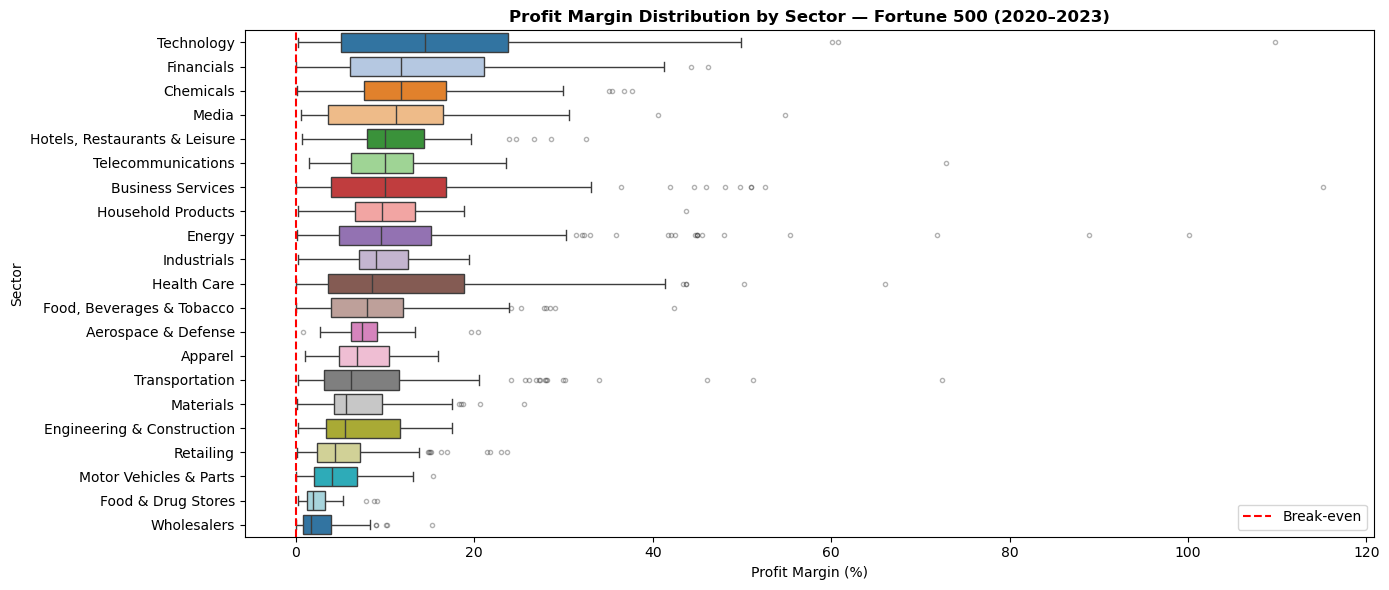

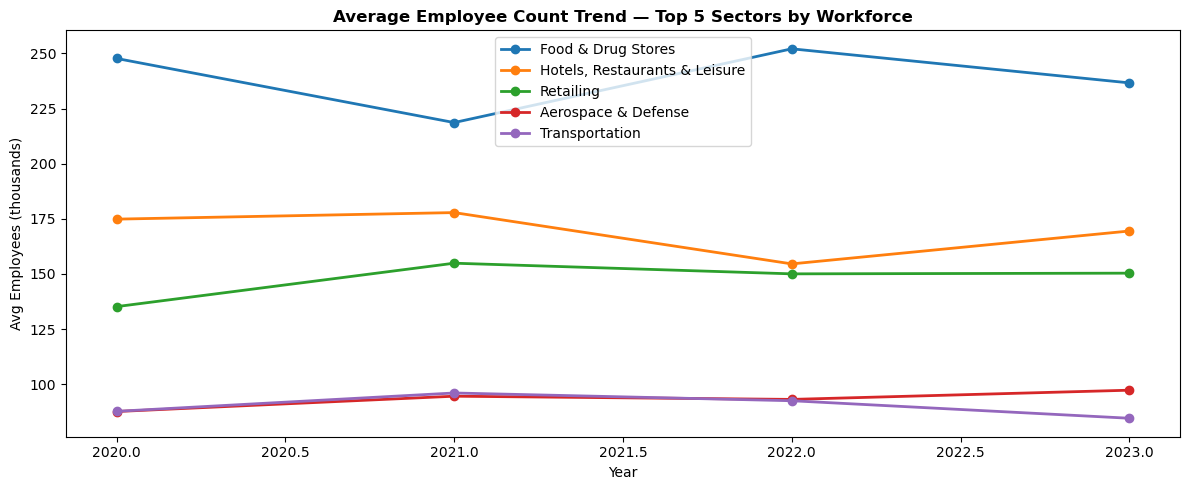

In [34]:
# ── Summary Visualisation — Profit Margin Distribution by Sector ─────────
fig, ax = plt.subplots(figsize=(14, 6))
order_pm = df.groupby('sector')['profit_margin'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='sector', x='profit_margin', order=order_pm, ax=ax, palette='tab20',
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
ax.set_title('Profit Margin Distribution by Sector — Fortune 500 (2020–2023)', fontweight='bold')
ax.set_xlabel('Profit Margin (%)'); ax.set_ylabel('Sector')
ax.legend()
plt.tight_layout(); plt.show()

# ── Year-over-year employee count change ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
emp_trend = df.groupby(['year','sector'])['employees'].mean().reset_index()
top_sec5  = df.groupby('sector')['employees'].mean().nlargest(5).index
for sec in top_sec5:
    sub = emp_trend[emp_trend['sector']==sec]
    ax.plot(sub['year'], sub['employees']/1e3, marker='o', linewidth=2, label=sec)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Employees (thousands)')
ax.set_title('Average Employee Count Trend — Top 5 Sectors by Workforce', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### 7.1 Dataset Limitations

- **Survivorship Bias:** The dataset only includes companies that made it to the Fortune 500 list — companies that failed or were delisted during 2020–2023 are not represented, which may overestimate average financial performance.
- **Short Time Window:** Only 4 years (2020–2023) are covered, which includes the COVID-19 recovery period. Trends observed may not generalise to longer time horizons.
- **Top 500 Only:** The dataset represents only the largest U.S. companies by revenue — findings cannot be generalised to small or mid-cap companies.
- **Derived Columns:** `profit_margin`, `revenue_per_employee`, and `return_on_assets` are computed columns, not original reported values — any errors in base columns propagate to these metrics.
- **Missing Values:** Some companies have missing entries for certain years, which may introduce bias in year-over-year comparisons.
- **No Macroeconomic Context:** External factors like inflation, interest rates, or geopolitical events are not captured in the dataset, limiting causal interpretation of trends.

## 8. Summary of Findings & Industry-Relevant Conclusions

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Revenue & profit are right-skewed** — a handful of mega-companies (Walmart, Amazon, Apple) dominate | Histograms, five-number summary |
| 2 | **Technology sector shows the highest average market value** despite not having the highest revenue | Sector bar charts, scatter plots |
| 3 | **Revenue grew significantly from 2020 to 2023** (t-test p < 0.05) | Two-sample t-test |
| 4 | **Profit varies significantly across sectors** (one-way ANOVA p < 0.001) | ANOVA results |
| 5 | **Global 500 companies are over-represented in Technology** — Bayes analysis confirms ~67% probability | Conditional probability, Bayes |
| 6 | **Female CEO presence remains low (~8%)** with no significant association to Global 500 membership | Chi-square test |
| 7 | **Energy sector shows high revenue but moderate profit margins** — exposed to commodity price volatility | Boxplots, profit margin analysis |
| 8 | **Several companies show consistent losses**, representing risk flags for investors | Outlier analysis |
